<a href="https://colab.research.google.com/github/HarshithReddy01/Algorithms-Practice/blob/master/K_nearest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

In [4]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std  = sc.transform(X_test)

In [5]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined      = np.hstack((y_train, y_test))

In [6]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors  = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap    = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black',
                    alpha=1.0, linewidth=1,
                    marker='o', s=100, label='Test set')

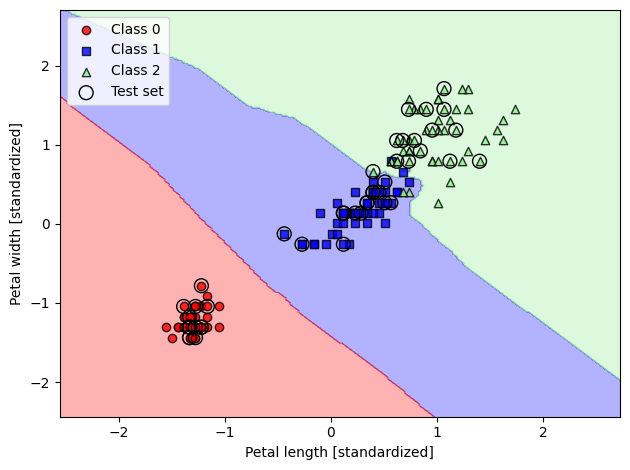

In [7]:
knn = KNeighborsClassifier(n_neighbors=5,
                           p=2,
                           metric='minkowski')

knn.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std,
                      y_combined,
                      classifier=knn,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
y_pred = knn.predict(X_test_std)

print(f'Misclassified: {(y_test != y_pred).sum()}')
print(f'Accuracy:      {accuracy_score(y_test, y_pred):.3f}')

Misclassified: 0
Accuracy:      1.000


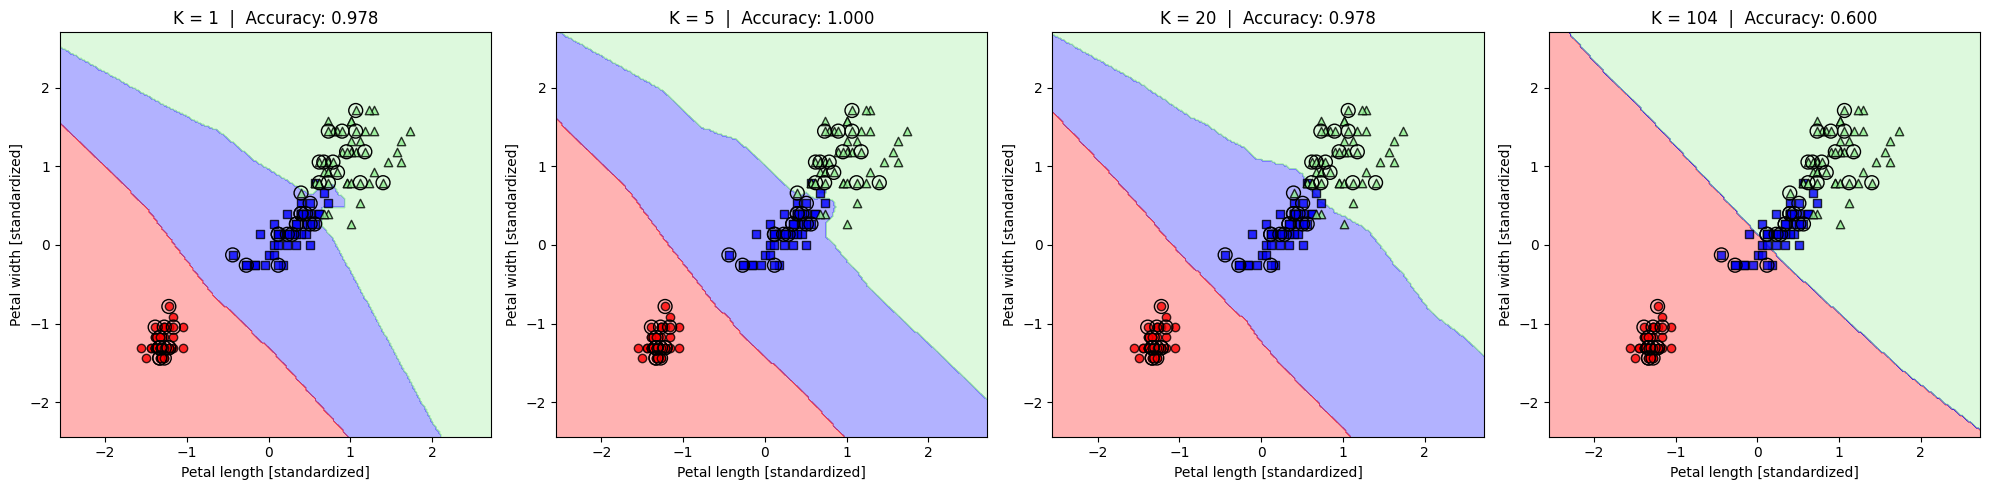

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

k_values = [1, 5, 20, 104]

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k,
                               p=2,
                               metric='minkowski')
    knn.fit(X_train_std, y_train)

    plt.sca(ax)
    plot_decision_regions(X_combined_std,
                          y_combined,
                          classifier=knn,
                          test_idx=range(105, 150))

    score = knn.score(X_test_std, y_test)
    ax.set_title(f'K = {k}  |  Accuracy: {score:.3f}')
    ax.set_xlabel('Petal length [standardized]')
    ax.set_ylabel('Petal width [standardized]')

plt.tight_layout()
plt.show()